In [1]:
# fits Homework10
# 3 FITS Files
# 3.1 Read FITS Files
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

In [2]:
fits_files = ["M13_0001.fits", "M13_0002.fits", "M13_0003.fits", "M13_0004.fits", "M13_0005.fits"]
image_list=[]

for filename in fits_files:
    hdulist = fits.open(filename)
    image_data = hdulist[0].data 
    image_list.append(image_data)

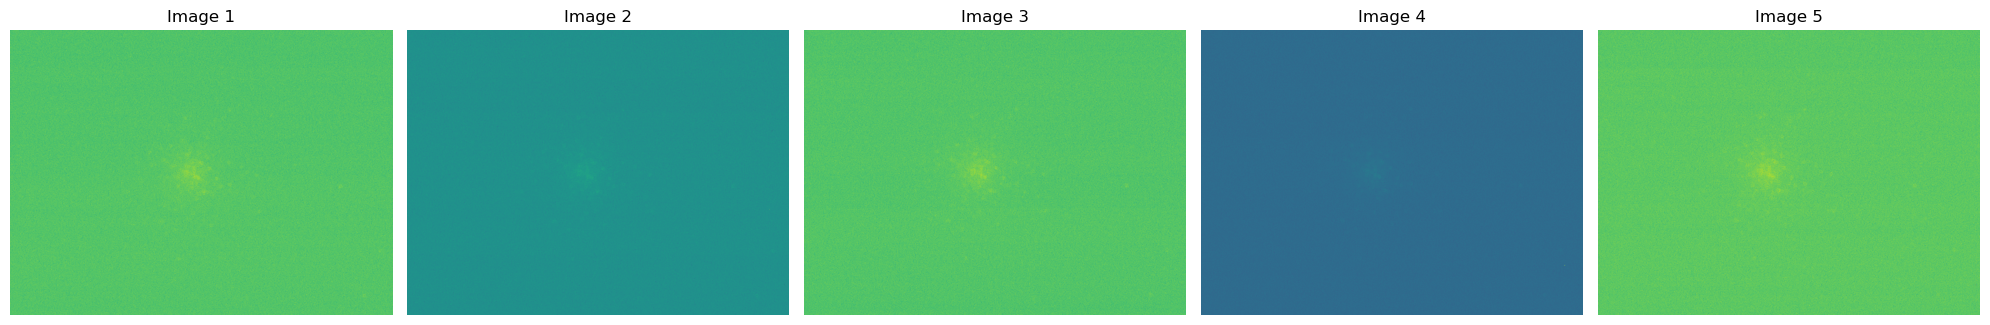

In [3]:
# 3.2 Plot Images
plt.figure(figsize=(20, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(image_list[i], origin="lower")
    plt.title(f"Image {i+1}")
    plt.axis("off")
    
plt.tight_layout()
plt.show()


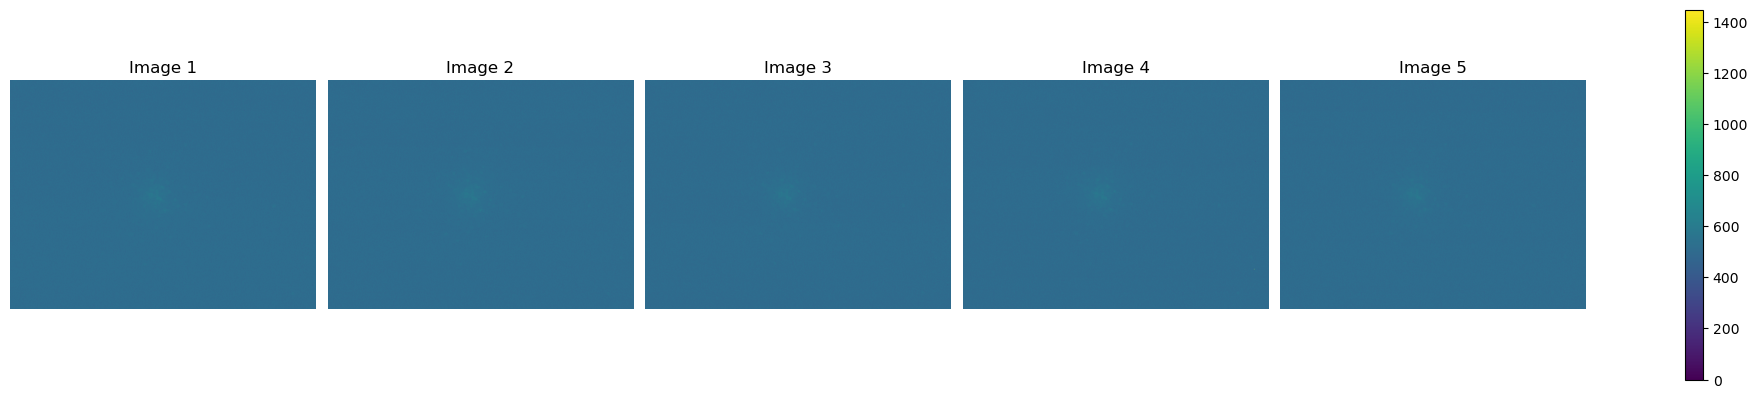

In [4]:
vmin = min([np.min(img) for img in image_list])
vmax = max([np.max(img) for img in image_list])

plt.figure(figsize=(20, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    im = plt.imshow(image_list[i], origin="lower",
                    vmin=vmin, vmax=vmax)
    plt.title(f"Image {i+1}")
    plt.axis("off")
    
plt.tight_layout()
plt.colorbar(im, ax=plt.gcf().get_axes(), location='right')
plt.show()

# These images all are in the same color, whereas in the last plot the colors were not scaled the same between the images.

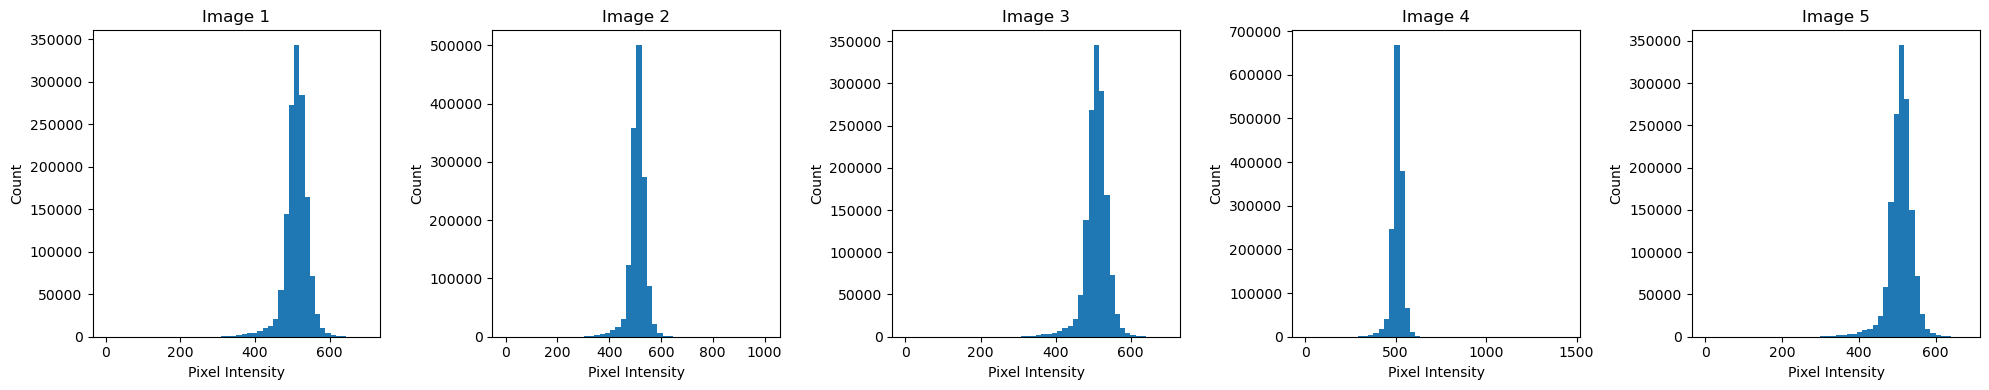

In [5]:
# 3.3 Plot Histograms
plt.figure(figsize=(20, 4))

for i, img in enumerate(image_list):
    plt.subplot(1, 5, i + 1)
    plt.hist(img.ravel(), bins=50)
    plt.title(f"Image {i+1}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [6]:
# a) The x-axis is the brightness of each pixel and the y-axis is the number of pixels at that brightness.
# b) The range of pixel instensities is divided into 50 equal groups.
# c) Most of the data is centered around 500.
# d) The data is not very spread. It is very concentrated around a few values.
for i, img in enumerate(image_list):
    mean_val = np.mean(img)
    median_val = np.median(img)
    print(f"Image {i+1}: mean = {mean_val:.2f}, median = {median_val:.2f}")

Image 1: mean = 510.47, median = 512.00
Image 2: mean = 509.75, median = 511.00
Image 3: mean = 508.05, median = 510.00
Image 4: mean = 507.91, median = 509.00
Image 5: mean = 508.79, median = 510.00


In [7]:
# 3.4.1
combined_image = np.median(image_list, axis=0)
combined_median = np.median(combined_image)
print(combined_median)
# the new median intensity is 510.

510.0


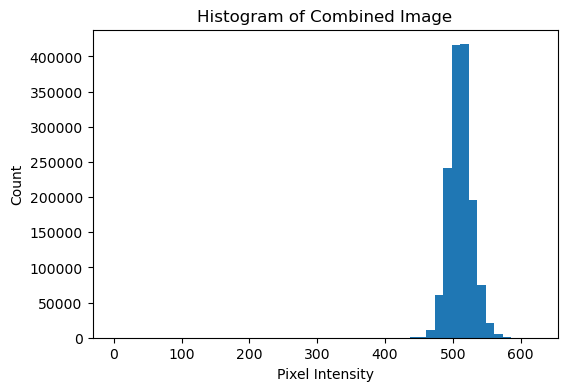

In [8]:
# 3.4.2
plt.figure(figsize=(6,4))
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.title("Histogram of Combined Image")
plt.show()

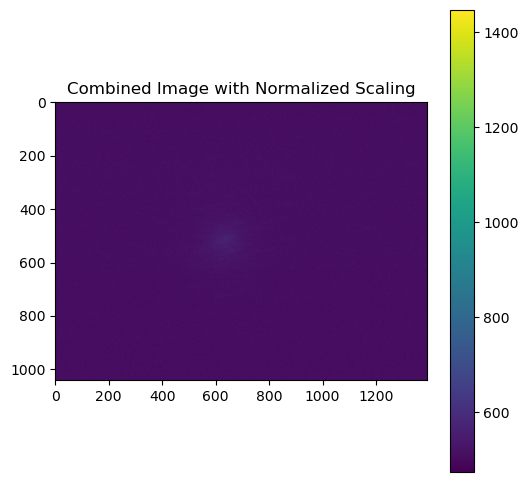

In [9]:
# 3.4.3
vmin = np.percentile(combined_image, 1)
vmin = np.percentile(combined_image, 1)

plt.figure(figsize=(6,6))
plt.imshow(combined_image, vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image with Normalized Scaling")
plt.show()

In [10]:
# 3.4.4
# The object is easier to see in this image, and there seems to be less noise

In [11]:
# 3.4.5
fits.writeto("combined.fits", combined_image, overwrite=True)